In [93]:
import wrds
import datetime
import numpy as np
import pandas as pd
from itertools import chain
import seaborn as sns
import matplotlib.pyplot as plt

In [94]:



# Matteo's original actions and stakeholders
def dict_2d_actions_stakeholders_original_matteo(signal_0_name="advocacy", signal_1_name="preparation", signal_2_name="transformation"):
    
    return{
        # 'TYPE: association': 0, 
        # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
        'TYPE: donation & funding': 0, 
        'TYPE: volunteerism': 0, 
        'TYPE_SREC: communication - local communities and society': 0, 
        'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
        'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
        'TYPE_SREC: organizational structuring - local communities and society': 0, 

        'TYPE: adoption of standards and rules': 1, 
        'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
        'TYPE_SREC: communication - employees': 1, 
        'TYPE_SREC: training - employees': 1, 
        'TYPE_SREC: incentives - employees': 1, 
        'TYPE_SREC: organizational structuring - employees': 1, 

        'TYPE: asset modification': 2,
        'TYPE: modification of procedures': 2, 
        'TYPE: new products': 2, 
        'TYPE: r&d investments': 2, 
        'TYPE_SREC: communication - customers': 2, 
        'TYPE_SREC: communication - shareholders': 2, 
        'TYPE_SREC: communication - suppliers': 2, 
        'TYPE_SREC: training - customers': 2, 
        'TYPE_SREC: training - shareholders': 2, 
        'TYPE_SREC: training - suppliers': 2, 
        'TYPE_SREC: incentives - customers': 2, 
        'TYPE_SREC: incentives - shareholders': 2, 
        'TYPE_SREC: incentives - suppliers': 2, 
        'TYPE_SREC: organizational structuring - customers': 2, 
        'TYPE_SREC: organizational structuring - shareholders': 2, 
        'TYPE_SREC: organizational structuring - suppliers': 2, 
    }, signal_0_name, signal_1_name, signal_2_name

categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()

### 4. EDA

In [ ]:
#Golden Dataset Location
from pathlib import Path
import os

golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)

#lc = pd.read_csv(golden_location / "LC_dataset_v_2A.csv")
lc = pd.read_csv(golden_location / "LC_dataset_v_2B1_20260409.csv")



start_year = 2013
end_year = 2024
lc = lc[lc['rfyear'] >= start_year]
lc = lc[lc['rfyear'] <= end_year]
lc = lc[lc['loc'] == 'JPN']


C:\Users\chris\AppData\Local\Temp\ipykernel_6276\568193564.py:5: DtypeWarning: Columns (514) have mixed types. Specify dtype option on import or set low_memory=False.
  lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')


In [96]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Sum Activites Stats

In [97]:

# multiple stats per year
lc.groupby("rfyear")["sum_activities"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,43.386707,46.749769,2.0,14.0,28.0,54.5,322.0
2014,376.0,46.773936,51.760005,1.0,14.0,30.0,61.0,388.0
2015,383.0,44.224543,47.147721,2.0,14.0,29.0,56.0,281.0
2016,432.0,38.067130,44.587802,1.0,11.0,23.0,47.0,271.0
2017,449.0,35.037862,40.934681,1.0,10.0,20.0,42.0,246.0
2018,489.0,29.441718,34.299984,1.0,10.0,18.0,34.0,270.0
2019,545.0,27.754128,34.121567,1.0,10.0,17.0,31.0,373.0
2020,620.0,29.091935,37.289891,0.0,9.0,18.0,32.0,418.0
2021,725.0,29.801379,39.998125,1.0,9.0,17.0,32.0,465.0


Advocacy Stats

In [98]:
lc.groupby("rfyear")["signal_0"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,0.447495,0.215953,0.0,0.312500,0.434783,0.562178,1.0
2014,376.0,0.419523,0.216440,0.0,0.285714,0.398276,0.531771,1.0
2015,383.0,0.397067,0.217238,0.0,0.250000,0.375000,0.513986,1.0
2016,432.0,0.426976,0.224098,0.0,0.266667,0.400000,0.571429,1.0
2017,449.0,0.417430,0.221213,0.0,0.263158,0.400000,0.555556,1.0
2018,489.0,0.408355,0.227060,0.0,0.263158,0.392857,0.545455,1.0
2019,545.0,0.383774,0.226852,0.0,0.230769,0.375000,0.500000,1.0
2020,619.0,0.386351,0.232372,0.0,0.244048,0.363636,0.500000,1.0
2021,725.0,0.357412,0.227682,0.0,0.200000,0.333333,0.500000,1.0


Preparation Stats

In [99]:
lc.groupby("rfyear")["signal_1"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,0.248461,0.160167,0.0,0.144599,0.238095,0.355958,0.750
2014,376.0,0.257505,0.162166,0.0,0.142857,0.250000,0.356527,1.000
2015,383.0,0.279765,0.175776,0.0,0.163978,0.282609,0.380617,1.000
2016,432.0,0.258415,0.165411,0.0,0.136782,0.260870,0.363636,1.000
2017,449.0,0.275967,0.172569,0.0,0.160000,0.266667,0.384615,1.000
2018,489.0,0.278927,0.177844,0.0,0.157895,0.269231,0.400000,1.000
2019,545.0,0.261611,0.178811,0.0,0.136364,0.250000,0.380952,0.875
2020,619.0,0.264431,0.183382,0.0,0.142857,0.250000,0.369925,1.000
2021,725.0,0.257629,0.175026,0.0,0.142857,0.250000,0.368421,1.000


Transformation Stats

In [100]:
lc.groupby("rfyear")["signal_2"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,0.304044,0.166676,0.0,0.200000,0.300000,0.388889,1.0
2014,376.0,0.322972,0.181002,0.0,0.209497,0.316986,0.409091,1.0
2015,383.0,0.323167,0.167867,0.0,0.206623,0.314286,0.423660,1.0
2016,432.0,0.314609,0.182204,0.0,0.200000,0.285714,0.409091,1.0
2017,449.0,0.306603,0.180097,0.0,0.200000,0.283019,0.405405,1.0
2018,489.0,0.312718,0.187980,0.0,0.200000,0.300000,0.411765,1.0
2019,545.0,0.354615,0.218828,0.0,0.208333,0.333333,0.461538,1.0
2020,619.0,0.349218,0.200262,0.0,0.222222,0.333333,0.450000,1.0
2021,725.0,0.384959,0.208062,0.0,0.250000,0.363636,0.500000,1.0


In [101]:
lc.loc[lc['loc'] == 'JPN', 'gvkey'].unique().shape

(1278,)

In [102]:
# MANUAL INPUT

#change below to the above sdg - evn and non env>
plt_title_suffix = 'Innovation'
plt_max_to_min_title_suffix = 'Innovation to advocacy'

# FIND MIN AND MAX CATEGORY ID
min_category = min(categories_dict.values())
max_category = max(categories_dict.values())



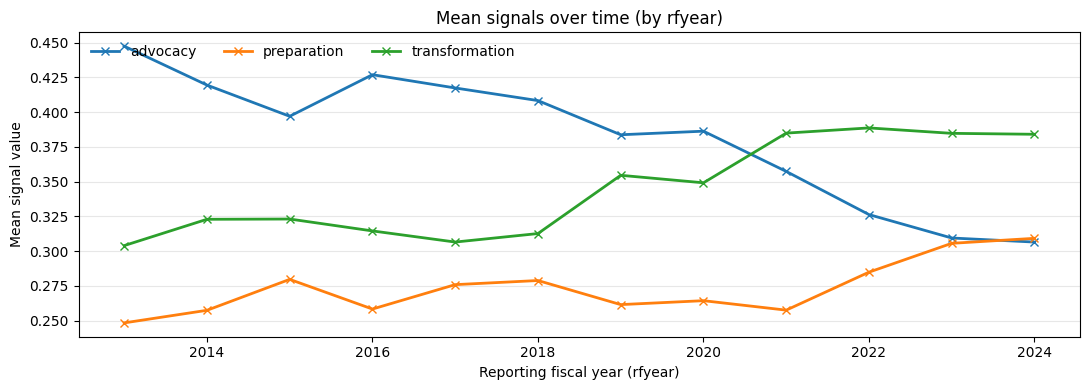

ValueError: lc is missing required columns: ['Industry']

In [103]:
# --------------------------------------------------------------
# Mean signals over time
# - (1) Mean signal_0/1/2 by rfyear
# - (2) Mean signal by rfyear × Industry over time
# --------------------------------------------------------------

from functions.eda_signal_plots import (
    ensure_signal_columns,
    plot_mean_signals_by_rfyear,
    plot_mean_signals_by_rfyear_industry,
)

# Ensure we have signal_0/1/2 columns (fallback: sum_with_0/1/2 divided by sum_activities)
lc_plot, sig_cols = ensure_signal_columns(lc)

signal_cols = sig_cols.as_list
signal_labels = [signal_0_name, signal_1_name, signal_2_name]

# (1) Mean of each signal by fiscal year
_ = plot_mean_signals_by_rfyear(
    lc_plot,
    rfyear_col="rfyear",
    signal_cols=signal_cols,
    signal_labels=signal_labels,
    marker="x",
    title="Mean signals over time (by rfyear)",
)

# (2) Mean signals by fiscal year and Industry over time
_ = plot_mean_signals_by_rfyear_industry(
    lc_plot,
    rfyear_col="rfyear",
    industry_col="Industry",
    signal_cols=signal_cols,
    signal_labels=signal_labels,
    plot_top_n=10,
    marker="x",
)


##### REGION

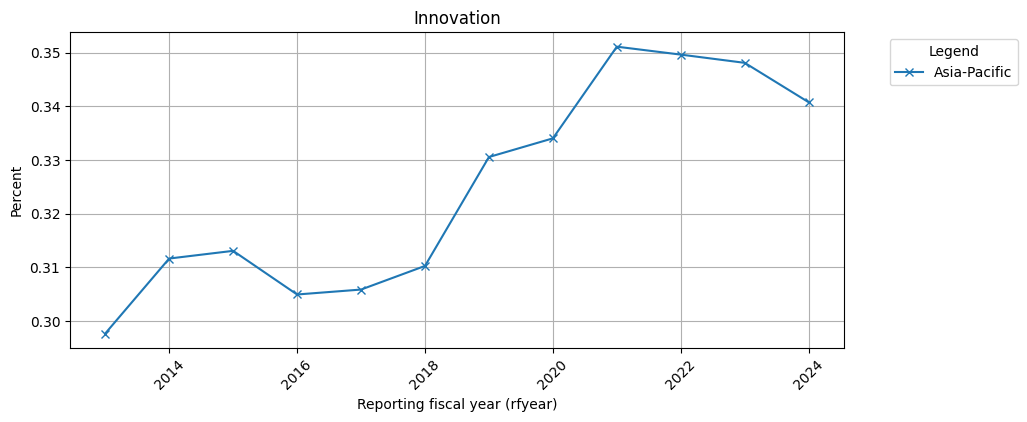

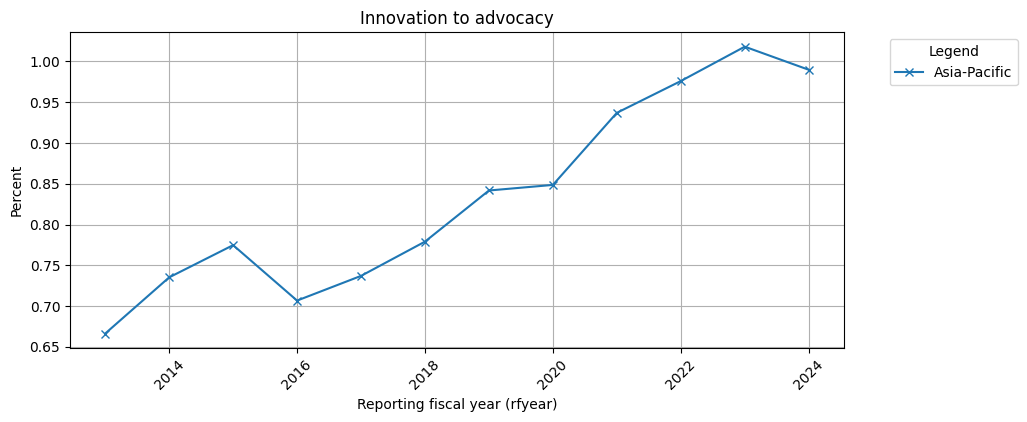

In [ ]:
# =================================================================================
# HEADLINE
# =================================================================================

# Generate aggregate versions of `ratio`
ratio_region_long = lc.groupby(['MacroRegion', 'rfyear'])[[f'sum_with_{max_category}', 'sum_activities']].agg(['sum']).reset_index()
ratio_region_long['ratio'] = ratio_region_long[f'sum_with_{max_category}']/ratio_region_long[f'sum_activities']
ratio_region = pd.pivot(ratio_region_long, index='rfyear', columns='MacroRegion', values='ratio')

# Iterate over each column in the DataFrame to plot
for column in ratio_region.columns:
    plt.plot(ratio_region.index, ratio_region[column], marker='x', linestyle='-', label=column)

plt.title(f'{plt_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/headline_region_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# =================================================================================
# CORE
# =================================================================================

# Generate aggregate versions of `ratio_max_to_min`
ratio_max_to_min_region_long = lc.groupby(['MacroRegion', 'rfyear'])[[f'sum_with_{min_category}', f'sum_with_{max_category}']].agg(['sum']).reset_index()
ratio_max_to_min_region_long['ratio_max_to_min'] = ratio_max_to_min_region_long[f'sum_with_{max_category}']/ratio_max_to_min_region_long[f'sum_with_{min_category}']
ratio_max_to_min_region = pd.pivot(ratio_max_to_min_region_long, index='rfyear', columns='MacroRegion', values='ratio_max_to_min')

# Iterate over each column in the DataFrame to plot
for column in ratio_max_to_min_region.columns:
    plt.plot(ratio_max_to_min_region.index, ratio_max_to_min_region[column], marker='x', linestyle='-', label=column)

plt.title(f'{plt_max_to_min_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/core_region_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

##### GICS

In [ ]:
def map_sectors(x):
    # Skip Industrials, Health Care, Utilities
    if x in ['Energy', 'Materials']:
        return 'Primary Industries'
    elif x in ['Consumer Discretionary', 'Consumer Staples']:
        return 'Consumer'

    # make Financial = Financials if you want to include finance sector
    elif x in ['Financials', 'Real Estate']:
        return 'Financial'
    elif x in ['Communication Services', 'Information Technology']:
        return 'ICT'
    return x

In [ ]:
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)

In [ ]:
# Define a CVD-friendly colour map and line styles
colours = plt.cm.viridis(np.linspace(0, 1, len(lc['Industry'].unique())))
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'x', '*']

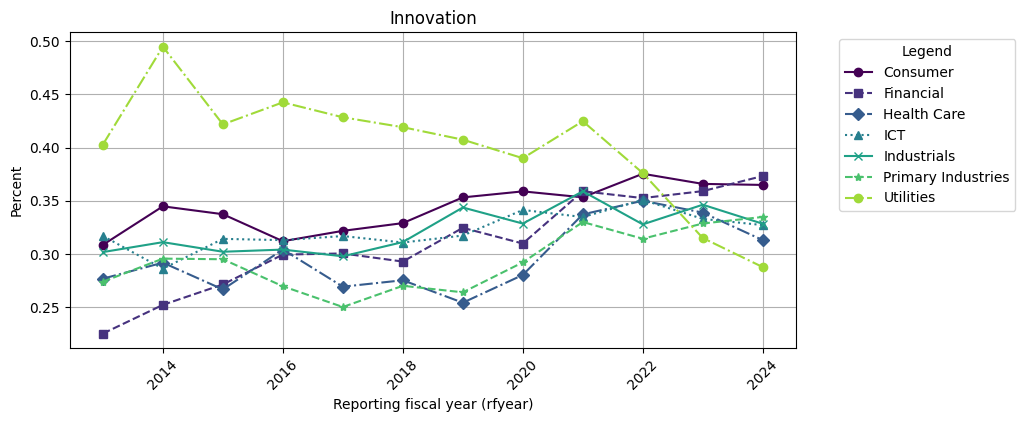

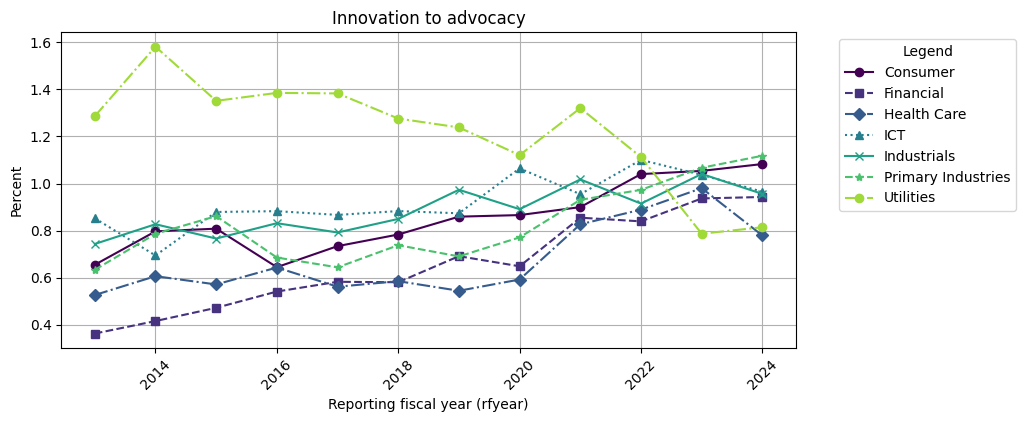

In [ ]:
# =================================================================================
# HEADLINE
# =================================================================================

# Generate aggregate versions of `ratio`
ratio_gics_long = lc.groupby(['Industry', 'rfyear'])[[f'sum_with_{max_category}', 'sum_activities']].agg(['sum']).reset_index()
ratio_gics_long['ratio'] = ratio_gics_long[f'sum_with_{max_category}']/ratio_gics_long[f'sum_activities']
ratio_gics = pd.pivot(ratio_gics_long, index='rfyear', columns='Industry', values='ratio')

# Iterate over each column in the DataFrame to plot
# Plot each column in the DataFrame
for idx, (column, colour) in enumerate(zip(ratio_gics.columns, colours)):
    plt.plot(ratio_gics.index, ratio_gics[column],
                label=column, color=colour,
                linestyle=line_styles[idx % len(line_styles)],
                marker=markers[idx % len(markers)])

plt.title(f'{plt_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/headline_gics_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# =================================================================================
# CORE
# =================================================================================

# Generate aggregate versions of `ratio_max_to_min`
ratio_max_to_min_gics_long = lc.groupby(['Industry', 'rfyear'])[[f'sum_with_{min_category}', f'sum_with_{max_category}']].agg(['sum']).reset_index()
ratio_max_to_min_gics_long['ratio_max_to_min'] = ratio_max_to_min_gics_long[f'sum_with_{max_category}']/ratio_max_to_min_gics_long[f'sum_with_{min_category}']
ratio_max_to_min_gics = pd.pivot(ratio_max_to_min_gics_long, index='rfyear', columns='Industry', values='ratio_max_to_min')

# Iterate over each column in the DataFrame to plot
for idx, (column, colour) in enumerate(zip(ratio_max_to_min_gics.columns, colours)):
    plt.plot(ratio_max_to_min_gics.index, ratio_max_to_min_gics[column],
                label=column, color=colour,
                linestyle=line_styles[idx % len(line_styles)],
                marker=markers[idx % len(markers)])

plt.title(f'{plt_max_to_min_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/core_gics_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

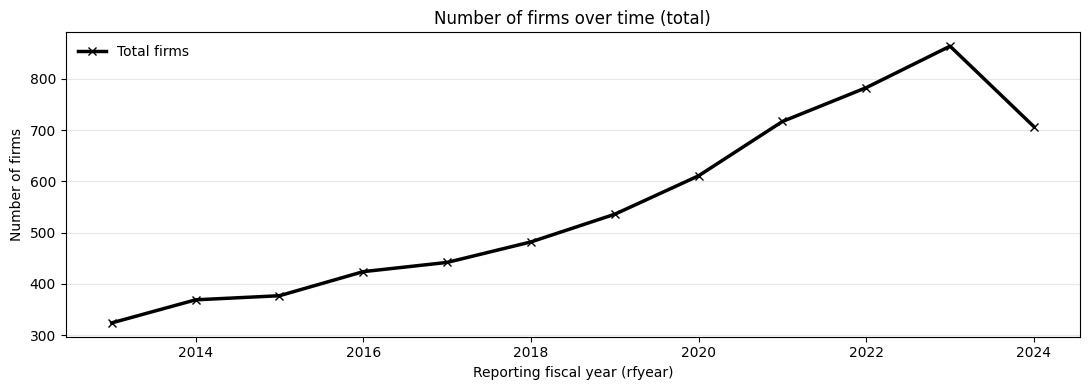

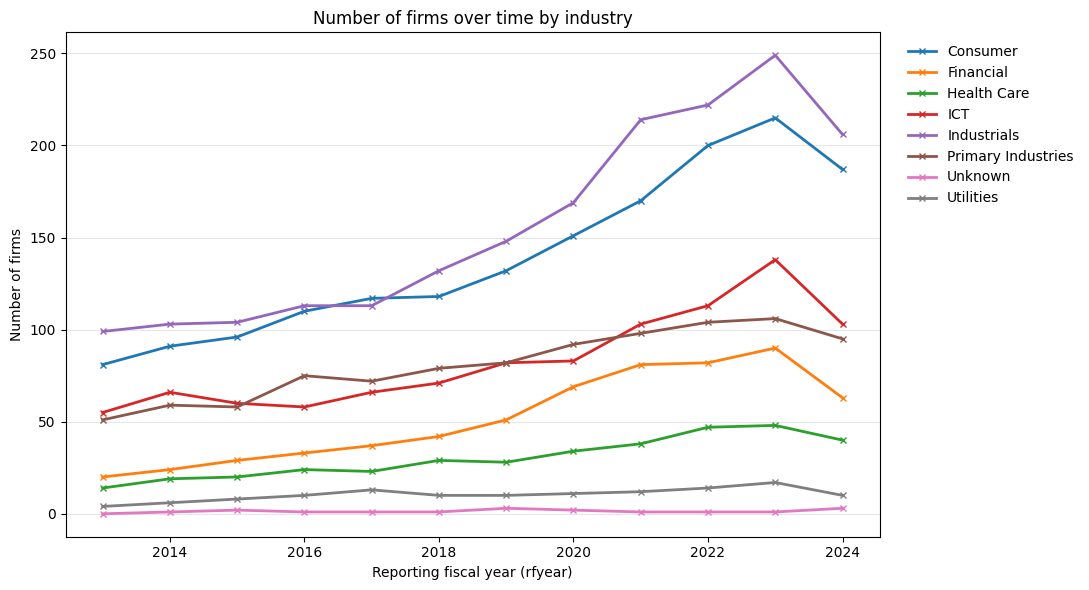

In [ ]:
# Total number of firms over time (split by industry)
plot_top_n = 10  # keep plot readable; set to None to show all industries

# `lc` is the main long-format dataset used throughout this notebook.
tmp = lc[['gvkey', 'rfyear', 'Industry']].dropna(subset=['gvkey', 'rfyear']).copy()
tmp['Industry'] = tmp['Industry'].fillna('Unknown').astype(str)

firm_counts = tmp.groupby(['rfyear', 'Industry'])['gvkey'].nunique().reset_index(name='n_firms')
total_counts = tmp.groupby('rfyear')['gvkey'].nunique().sort_index()

pivot = (
    firm_counts
    .pivot(index='rfyear', columns='Industry', values='n_firms')
    .fillna(0)
    .sort_index()
)

industry_sums = pivot.sum(axis=0).sort_values(ascending=False)
if plot_top_n is not None and pivot.shape[1] > plot_top_n:
    top_industries = industry_sums.head(plot_top_n).index
    other_industries = industry_sums.index.difference(top_industries)
    pivot_plot = pivot[top_industries].copy()
    if len(other_industries) > 0:
        pivot_plot['Other'] = pivot[other_industries].sum(axis=1)
else:
    pivot_plot = pivot

# -----------------------------------------------------------------
# Plot 1: total firms over time
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    total_counts.index,
    total_counts.values,
    color='black',
    linewidth=2.5,
    label='Total firms',
    marker='x',
    markersize=6,
)
ax.set_title('Number of firms over time (total)')
ax.set_xlabel('Reporting fiscal year (rfyear)')
ax.set_ylabel('Number of firms')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# Plot 2: firms over time split by industry
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))
for col in pivot_plot.columns:
    ax.plot(
        pivot_plot.index,
        pivot_plot[col].values,
        linewidth=2,
        label=str(col),
        marker='x',
        markersize=4,
    )
ax.set_title('Number of firms over time by industry')
ax.set_xlabel('Reporting fiscal year (rfyear)')
ax.set_ylabel('Number of firms')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
plt.tight_layout()
plt.show()
